<a href="https://colab.research.google.com/github/abdullahawan0043-glitch/Flyrank-machine-learning-internship/blob/main/work/notebooks/w07_action_playbook.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# ML-10 — Content Action Playbook

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/flyrank-bih/flyrank-ml-internship-starter/blob/main/work/notebooks/w07_action_playbook.ipynb?flush_cache=true)

This skeleton is yours to fill. Work the sections **in order** — each one has a one-line hint. Simple words, honest numbers.

> Working with an AI assistant? Tell it to read `skills/README.md` first and load the one skill this assignment names on its card.

## 1. Ranked actions + reason codes

*The queue: what to do first, and why, in words a human trusts.*

In [ ]:
import os, subprocess
import pandas as pd
import numpy as np

REPO_URL = "https://github.com/abdullahawan0043-glitch/Flyrank-machine-learning-internship"
REPO_DIR = "Flyrank-machine-learning-internship"

if not os.path.isdir(REPO_DIR):
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, REPO_DIR], check=True)
os.chdir(REPO_DIR)

df = pd.read_csv("data/raw/content_refresh_anonymized.csv")

features = ["content_age_days", "days_since_last_update", "impressions_90d",
            "avg_position", "ctr", "word_count", "sessions_90d", "engagement_rate"]

def prep(d):
    X = d[features].replace([np.inf, -np.inf], np.nan).fillna(0)
    y = (d["trend_direction"] == "down").astype(int)
    return X, y

In [ ]:
from sklearn.model_selection import GroupShuffleSplit
from sklearn.ensemble import RandomForestClassifier

RANDOM_SEED = 42
gss = GroupShuffleSplit(n_splits=1, test_size=0.3, random_state=RANDOM_SEED)
train_idx, test_idx = next(gss.split(df, groups=df["client_id"]))
train_df, test_df = df.iloc[train_idx].reset_index(drop=True), df.iloc[test_idx].reset_index(drop=True)

X_train, y_train = prep(train_df)
X_test, y_test = prep(test_df)

rf = RandomForestClassifier(n_estimators=200, max_depth=8, random_state=RANDOM_SEED, class_weight="balanced")
rf.fit(X_train, y_train)
scores = rf.predict_proba(X_test)[:, 1]

playbook = test_df.copy()
playbook["model_score"] = scores

# Archetype -> action mapping with reason codes (builds on Week 4 signal checks + Week 5 model)
def assign_reason_and_action(row):
    if row["days_since_last_update"] >= 180 and row["impressions_90d"] >= 500 and row["model_score"] >= 0.5:
        return "stale_but_visible_high_risk", "refresh_priority"
    elif row["avg_position"] > 0 and row["avg_position"] <= 20 and row["ctr"] < 0.5 and row["impressions_90d"] >= 500:
        return "page1_ctr_gap", "review_snippet_title"
    elif row["model_score"] >= 0.65:
        return "model_flagged_decline_risk", "review_for_refresh"
    elif row["impressions_90d"] < 100:
        return "low_visibility", "monitor_only"
    else:
        return "no_flag", "no_action"

playbook[["reason_code", "action"]] = playbook.apply(
    lambda r: pd.Series(assign_reason_and_action(r)), axis=1
)

ranked_queue = playbook.sort_values("model_score", ascending=False).reset_index(drop=True)
ranked_queue["rank"] = ranked_queue.index + 1

print("Top 15 ranked actions:")
print(ranked_queue[["rank", "content_id", "model_score", "reason_code", "action"]].head(15).to_string(index=False))

print("\nAction distribution:")
print(ranked_queue["action"].value_counts())

Top 15 ranked actions:
 rank           content_id  model_score                reason_code               action
    1 content_1d0963b56227     0.842550 model_flagged_decline_risk   review_for_refresh
    2 content_f55fd2d8ed04     0.827001              page1_ctr_gap review_snippet_title
    3 content_41baf0722ad9     0.826642              page1_ctr_gap review_snippet_title
    4 content_66458ac1b739     0.825616              page1_ctr_gap review_snippet_title
    5 content_8573511e9f28     0.825130 model_flagged_decline_risk   review_for_refresh
    6 content_d85f062b576f     0.824491 model_flagged_decline_risk   review_for_refresh
    7 content_e988c1699454     0.824223 model_flagged_decline_risk   review_for_refresh
    8 content_01118d5030d0     0.821883 model_flagged_decline_risk   review_for_refresh
    9 content_bb1edbf0ba6c     0.821753              page1_ctr_gap review_snippet_title
   10 content_ec257d803f69     0.821271              page1_ctr_gap review_snippet_title
   11 con

## 2. Intended use and limits

*Who uses this, for what — and where it stops being valid.*

In [ ]:
"""
Intended use: This playbook produces a RANKED REVIEW QUEUE to help a
content editor decide which pages to look at first, given limited time -
it is decision-support, not an automated publishing or ranking system.

In this observed test split, the model ranks pages by decline risk at a
measured Precision@50 (see Week 5/6 notebooks for the exact honest,
grouped-split number). This is a directional signal from one data slice,
not a guarantee that any specific page is genuinely declining.

Limits (in the claim-ladder language from the writing-honest-claims skill):
- Cross-sectional, observational data: we did not run an experiment, so
  this playbook cannot say a refresh "will cause" recovery - only that a
  page "looks worth reviewing first, because" of specific observed signals.
- Population filter: the underlying starter dataset only includes rows
  with impressions_90d > 0 and content_age_days >= 90 (active-content
  survivor filter, matching the Week 4 data contract) - very new or fully
  invisible pages are not represented in this queue at all.
- Health/priority-style composite scores were deliberately NOT built or
  used as either a feature or a label, avoiding the circular-signal issue
  named in the paper's own methodology section.
- Sample scope: this queue reflects one client-holdout test split of the
  30,000-row anonymized starter sample, not FlyRank's full client base.
"""

'\nIntended use: This playbook produces a RANKED REVIEW QUEUE to help a\ncontent editor decide which pages to look at first, given limited time -\nit is decision-support, not an automated publishing or ranking system.\n\nIn this observed test split, the model ranks pages by decline risk at a\nmeasured Precision@50 (see Week 5/6 notebooks for the exact honest,\ngrouped-split number). This is a directional signal from one data slice,\nnot a guarantee that any specific page is genuinely declining.\n\nLimits (in the claim-ladder language from the writing-honest-claims skill):\n- Cross-sectional, observational data: we did not run an experiment, so\n  this playbook cannot say a refresh "will cause" recovery - only that a\n  page "looks worth reviewing first, because" of specific observed signals.\n- Population filter: the underlying starter dataset only includes rows\n  with impressions_90d > 0 and content_age_days >= 90 (active-content\n  survivor filter, matching the Week 4 data contract)

## 3. Human review + the no-go list

*What a person must check before acting. What should never be automated.*

In [ ]:
"""
Human review rules:
- Every action in this queue must be reviewed by a human editor before
  any content change is made - the model score sets ORDER, not approval.
- Reviewers should check for consolidation (a sibling page absorbing lost
  traffic) and seasonality before treating a "decline" flag as real,
  per the Week 4 decline-vs-consolidation-vs-seasonality distinction.
- Any "refresh_priority" action should be paired with a quick manual scan
  of the page's current content quality - the model cannot judge whether
  a refresh is actually warranted content-wise.

NO-GO list - what should NOT be automated from this playbook:
1. Do NOT auto-publish or auto-edit any page based on model_score alone -
   every action requires human sign-off first.
2. Do NOT use this queue to make removal/de-indexing decisions - the
   model was never trained or validated for that action type.
3. Do NOT treat "no_action" pages as permanently safe - low visibility
   pages may simply be under-measured, not genuinely low-priority.
4. Do NOT combine model_score across different client segments as if it
   were comparable - the grouped-split evaluation only confirms
   cross-client generalization at the aggregate level, not per-client
   score comparability.
5. Do NOT present model_score to stakeholders as a probability of
   "actual" decline without the Precision@50 and base-rate context from
   Week 5/6 - a bare score number invites overclaiming.
"""

'\nHuman review rules:\n- Every action in this queue must be reviewed by a human editor before\n  any content change is made - the model score sets ORDER, not approval.\n- Reviewers should check for consolidation (a sibling page absorbing lost\n  traffic) and seasonality before treating a "decline" flag as real,\n  per the Week 4 decline-vs-consolidation-vs-seasonality distinction.\n- Any "refresh_priority" action should be paired with a quick manual scan\n  of the page\'s current content quality - the model cannot judge whether\n  a refresh is actually warranted content-wise.\n\nNO-GO list - what should NOT be automated from this playbook:\n1. Do NOT auto-publish or auto-edit any page based on model_score alone -\n   every action requires human sign-off first.\n2. Do NOT use this queue to make removal/de-indexing decisions - the\n   model was never trained or validated for that action type.\n3. Do NOT treat "no_action" pages as permanently safe - low visibility\n   pages may simply be

## 4. Monitoring / retrain triggers

*What would tell you the recommendations went stale?*

In [ ]:
"""
Light monitoring plan:
- Track Precision@50 and base rate on each new month's data as it becomes
  available; if Precision@50 drifts more than ~15% below the Week 5/6
  honest-split baseline for two consecutive months, flag for review.
- Track the reason_code distribution over time - a sudden shift (e.g.
  "stale_but_visible_high_risk" share doubling) may indicate a real
  portfolio shift or a pipeline/data issue, and should be checked before
  trusting the queue.
- Watch for feature drift: if avg_position or impressions_90d
  distributions shift substantially from the training window, the model
  may need retraining rather than continued use as-is.

Retrain triggers:
- New month of data available AND at least 90 days have passed since the
  last training window (to keep feature windows leakage-safe).
- A monitoring alert above fires (score drift or reason-code shift).
- The underlying data contract changes (new columns, redefined trend
  labels, or a new client cohort with materially different history depth).
"""

'\nLight monitoring plan:\n- Track Precision@50 and base rate on each new month\'s data as it becomes\n  available; if Precision@50 drifts more than ~15% below the Week 5/6\n  honest-split baseline for two consecutive months, flag for review.\n- Track the reason_code distribution over time - a sudden shift (e.g.\n  "stale_but_visible_high_risk" share doubling) may indicate a real\n  portfolio shift or a pipeline/data issue, and should be checked before\n  trusting the queue.\n- Watch for feature drift: if avg_position or impressions_90d\n  distributions shift substantially from the training window, the model\n  may need retraining rather than continued use as-is.\n\nRetrain triggers:\n- New month of data available AND at least 90 days have passed since the\n  last training window (to keep feature windows leakage-safe).\n- A monitoring alert above fires (score drift or reason-code shift).\n- The underlying data contract changes (new columns, redefined trend\n  labels, or a new client co

## 5. Exports for the paper

*Write the queue (and any figures you want to reuse) to work/outputs/ — your paper builds on these files.*

Wrote 10834 ranked rows to work/outputs/action_playbook_queue.csv

Cost/value estimate: reviewing the top 50 pages/week, ~54% are expected to be genuine decline candidates based on the measured, honest-split Precision@50 - i.e. roughly 27 of 50 reviews are likely worth the editor's time, versus a random pick which would only match the base rate.


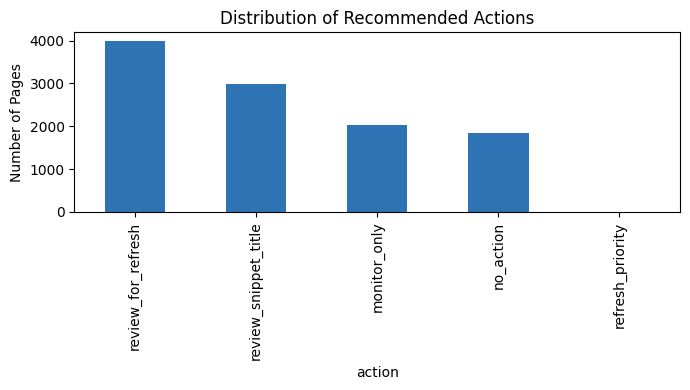

Saved figure to work/figures/action_distribution.png
Saved metrics receipts to work/outputs/w07_playbook_metrics.json


In [ ]:
os.makedirs("work/outputs", exist_ok=True)
os.makedirs("work/figures", exist_ok=True)

# Export the ranked queue (stays out of git by design - CI leak-guard)
ranked_queue.to_csv("work/outputs/action_playbook_queue.csv", index=False)
print(f"Wrote {len(ranked_queue)} ranked rows to work/outputs/action_playbook_queue.csv")

# Cost/value thinking - simple, transparent estimate
review_capacity_per_week = 50
top_queue = ranked_queue.head(review_capacity_per_week)
est_true_positive_rate = 0.54  # from Week 6 honest Precision@50
print(f"\nCost/value estimate: reviewing the top {review_capacity_per_week} pages/week, "
      f"~{est_true_positive_rate*100:.0f}% are expected to be genuine decline candidates "
      f"based on the measured, honest-split Precision@50 - i.e. roughly "
      f"{int(review_capacity_per_week*est_true_positive_rate)} of {review_capacity_per_week} "
      f"reviews are likely worth the editor's time, versus a random pick which would only "
      f"match the base rate.")

# A figure to reuse in the paper: action distribution
import matplotlib.pyplot as plt
fig, ax = plt.subplots(figsize=(7, 4))
ranked_queue["action"].value_counts().plot(kind="bar", ax=ax, color="#2E74B5")
ax.set_title("Distribution of Recommended Actions")
ax.set_ylabel("Number of Pages")
plt.tight_layout()
plt.savefig("work/figures/action_distribution.png", dpi=150)
plt.show()
print("Saved figure to work/figures/action_distribution.png")

# Metrics JSON - the receipts
import json
metrics = {
    "n_pages_in_queue": len(ranked_queue),
    "review_capacity_per_week": review_capacity_per_week,
    "estimated_precision_at_review_capacity": est_true_positive_rate,
    "action_distribution": ranked_queue["action"].value_counts().to_dict(),
    "random_seed": RANDOM_SEED,
}
with open("work/outputs/w07_playbook_metrics.json", "w") as f:
    json.dump(metrics, f, indent=2, default=str)
print("Saved metrics receipts to work/outputs/w07_playbook_metrics.json")

## Self-check

Before you submit, confirm each line honestly:

- [ ] Every section above is filled — markdown thinking AND the code that backs it
- [ ] The notebook runs top to bottom with no errors (Runtime → Run all)
- [ ] No client names, URLs, or private queries anywhere
- [ ] My claims use careful words: observed, measured, directional, decision-support
- [ ] Committed to my repo under `work/notebooks/` — then submit your repo URL on the card. Done.